# Supplemental Figures

Kendra Wyant  
May 20, 2024

In [ ]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(source("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true"))
suppressPackageStartupMessages(library(tidyposterior))

path_models_lag <- format_path(str_c("studydata/risk/models/lag"))


In [ ]:
test_metrics_0 <- read_csv(file.path(path_models_lag, 
                                        "test_metrics_1week_0_v2_nested.csv"), 
                              col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag0" = .estimate)

test_metrics_24 <- read_csv(file.path(path_models_lag, 
                                       "test_metrics_1week_24_v2_nested.csv"),
                             col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag24" = .estimate)

test_metrics_72 <- read_csv(file.path(path_models_lag, 
                                        "test_metrics_1week_72_v2_nested.csv"),
                              col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag72" = .estimate)

test_metrics_168 <- read_csv(file.path(path_models_lag, 
                                        "test_metrics_1week_168_v2_nested.csv"), 
                              col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag168" = .estimate)

test_metrics_336 <- read_csv(file.path(path_models_lag, 
                                       "test_metrics_1week_336_v2_nested.csv"),
                             col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag336" = .estimate)

test_metrics_all <- test_metrics_0 |> 
  left_join(test_metrics_24, by = c("outer_split_num")) |> 
  left_join(test_metrics_72, by = c("outer_split_num")) |>
  left_join(test_metrics_168, by = c("outer_split_num")) |>
  left_join(test_metrics_336, by = c("outer_split_num")) |> 
  mutate(fold_num = rep(1:10, 3),
         repeat_num = c(rep(1, 10), rep(2, 10), rep(3, 10))) |> 
  select(-outer_split_num)


### Full Posterior Distributions for auROC by Model

In [ ]:

# Repeated CV (id = repeat, id2 = fold within repeat)
# with a common variance:  statistic ~ model + (model | id2/id)
set.seed(101)
pp <- test_metrics_all |> 
  rename(id = repeat_num,
         id2 = fold_num) |> 
  perf_mod(formula = statistic ~ model + (1 | id2/id),
         transform = tidyposterior::logit_trans,  # for skewed & bounded AUC
         iter = 2000, chains = 4, adapt_delta = .99, # defaults but may increase to fix divergence issues
         family = gaussian, 
)  



SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 6.8e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.68 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 1.511 seconds (Warm-up)
Chain 1:                0.623 seconds (Sampling)
Chain 1:                2.13

In [ ]:

pp_tidy <- pp |> 
  tidy(seed = 123) 

q = c(.025, .5, .975)
test_metrics_all_pp_perf <- pp_tidy |> 
  group_by(model) |> 
  summarize(pp_median = quantile(posterior, probs = q[2]),
            pp_lower = quantile(posterior, probs = q[1]), 
            pp_upper = quantile(posterior, probs = q[3])) |> 
  mutate(model = factor(model, levels = c("lag0", "lag24", "lag72", "lag168", "lag336"),
                        labels = c("0 lag", "24 lag", "72 lag", "168 lag", "336 lag"))) |> 
  arrange(model)

test_metrics_all_pp_perf


# A tibble: 5 × 4
  model   pp_median pp_lower pp_upper
  <fct>       <dbl>    <dbl>    <dbl>
1 0 lag       0.868    0.848    0.885
2 24 lag      0.877    0.859    0.892
3 72 lag      0.868    0.848    0.884
4 168 lag     0.867    0.848    0.884
5 336 lag     0.846    0.825    0.865

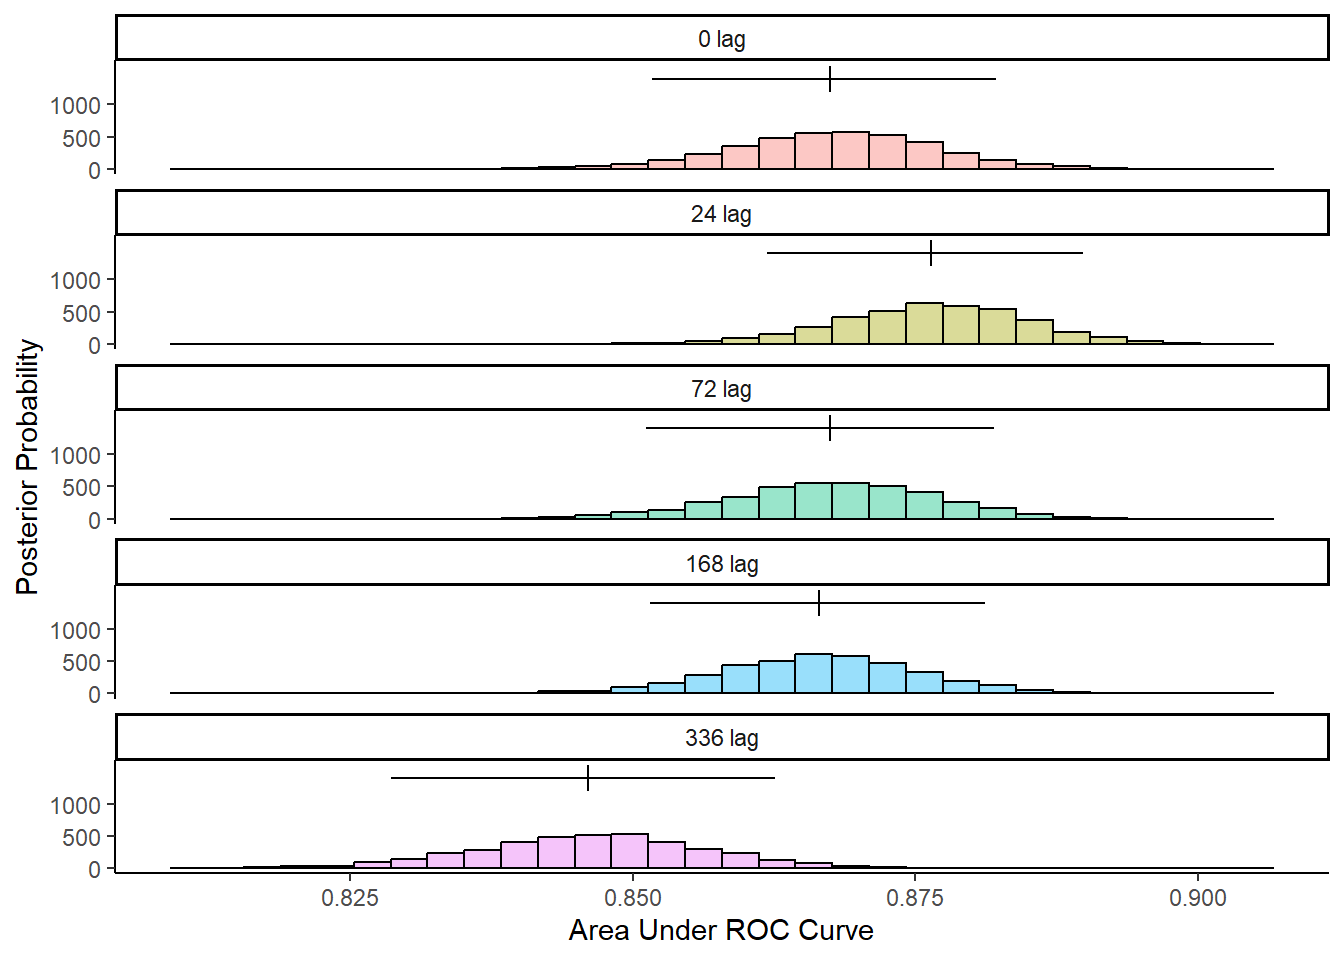

In [ ]:

ci <- pp_tidy |> 
  summary() |> 
  mutate(model = factor(model, levels = c("lag0", "lag24", "lag72", "lag168", "lag336"),
                        labels = c("0 lag", "24 lag", "72 lag", "168 lag", "336 lag")),
         y = 1400)

pp_tidy |> 
  mutate(model = factor(model, levels = c("lag0", "lag24", "lag72", "lag168", "lag336"),
                        labels = c("0 lag", "24 lag", "72 lag", "168 lag", "336 lag"))) |>
  ggplot() + 
  geom_histogram(aes(x = posterior, fill = model), color = "black", alpha = .4, 
                 bins = 30) +
  geom_segment(mapping = aes(y = y+200, yend = y-200, x = mean, xend = mean),
               data = ci) +
  geom_segment(mapping = aes(y = y, yend = y, x = lower, xend = upper),
                data = ci) +
  facet_wrap(~model, ncol = 1) +
  scale_y_continuous("Posterior Probability", breaks = c(0, 500, 1000)) +
  xlab("Area Under ROC Curve") +
  theme_classic() +
  theme(legend.position = "none")
